# Week 6: Regression

**Goal:** Apply regression models to predict a continuous target from audio features (e.g., emotional intensity 1 vs 2).  Evaluate with MSE and R².  Begin implementing Logistic Regression in MiniLearn.

**Deliverable:** `minilearn/regression.py` (LinearRegression + RidgeRegression) + this notebook.

---
## Project Tasks (from rubric)
- [ ] Finalize any remaining feature work from Week 5
- [ ] Choose a continuous regression target (intensity, or e.g., predicted MFCC mean)
- [ ] Implement `LinearRegression` and `RidgeRegression` in `minilearn/regression.py`
- [ ] Compare MiniLearn regression vs `sklearn.linear_model.LinearRegression`
- [ ] Evaluate with MSE, RMSE, R²
- [ ] Begin drafting `LogisticRegression` in `minilearn/classifiers.py`

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.regression import LinearRegression, RidgeRegression, mse, rmse, r2_score
from minilearn.preprocessing import StandardScaler, train_test_split
from sklearn.linear_model import LinearRegression as SklearnLR

DATA_DIR   = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\data'
OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Define the Regression Target

The RAVDESS intensity field (1 = normal, 2 = strong) can be treated as a continuous target for regression.  
Alternative: predict a continuous audio property such as mean RMS energy.

In [2]:
# Load the feature matrix saved by Week 5
feat_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'features.csv'))
feature_names = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'feature_names.csv'), header=None)[0].tolist()

# Intensity lives in the raw metadata — merge it in (rows match by construction)
meta_df = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
feat_df['intensity'] = meta_df['intensity'].values   # 1 = normal, 2 = strong

X     = feat_df[feature_names].values.astype(float)
y_reg = feat_df['intensity'].values.astype(float)

print(f'X shape  : {X.shape}')
print(f'y values : {np.unique(y_reg)}  (1 = normal, 2 = strong)')
print(f'Balance  : {dict(zip(*np.unique(y_reg, return_counts=True)))}')

# 80/20 split — stratify=False because intensity is treated as continuous
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, stratify=False
)

# Standardize features — fit on train only to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain : {len(y_train)} samples  (y mean = {y_train.mean():.3f})')
print(f'Test  : {len(y_test)}  samples  (y mean = {y_test.mean():.3f})')
print(f'Baseline MSE (predict mean) : {mse(y_test, np.full_like(y_test, y_train.mean())):.4f}')

X shape  : (2452, 112)
y values : [1. 2.]  (1 = normal, 2 = strong)
Balance  : {np.float64(1.0): np.int64(1320), np.float64(2.0): np.int64(1132)}

Train : 1961 samples  (y mean = 1.466)
Test  : 491  samples  (y mean = 1.444)
Baseline MSE (predict mean) : 0.2474


## 2. Linear Regression — MiniLearn vs sklearn

In [3]:
# ── MiniLearn — analytic (normal equations) ────────────────────────────────
ml_analytic = LinearRegression(solver='analytic')
ml_analytic.fit(X_train_s, y_train)
y_pred_analytic = ml_analytic.predict(X_test_s)

# ── MiniLearn — gradient descent ───────────────────────────────────────────
ml_gd = LinearRegression(solver='gradient_descent', lr=0.01, n_iter=1000)
ml_gd.fit(X_train_s, y_train)
y_pred_gd = ml_gd.predict(X_test_s)

# ── sklearn LinearRegression ────────────────────────────────────────────────
sk_lr = SklearnLR()
sk_lr.fit(X_train_s, y_train)
y_pred_sk = sk_lr.predict(X_test_s)

# ── Metrics table ────────────────────────────────────────────────────────────
print(f"{'Model':<30} {'MSE':>8} {'RMSE':>8} {'R²':>8}")
print('-' * 56)
for label, y_pred in [
    ('MiniLearn (analytic)',  y_pred_analytic),
    ('MiniLearn (grad desc)', y_pred_gd),
    ('sklearn LinearReg',     y_pred_sk),
]:
    print(f'{label:<30} {mse(y_test, y_pred):>8.4f} '
          f'{rmse(y_test, y_pred):>8.4f} '
          f'{r2_score(y_test, y_pred):>8.4f}')

# ── Coefficient agreement between MiniLearn analytic and sklearn ────────────
coef_diff = np.abs(ml_analytic.weights_ - sk_lr.coef_).max()
bias_diff  = abs(float(ml_analytic.bias_) - float(sk_lr.intercept_))
print(f'\nMax |w_minilearn − w_sklearn|  : {coef_diff:.2e}')
print(f'|bias_minilearn − bias_sklearn|: {bias_diff:.2e}')

Model                               MSE     RMSE       R²
--------------------------------------------------------
MiniLearn (analytic)             0.1722   0.4150   0.3024
MiniLearn (grad desc)            0.1718   0.4145   0.3040
sklearn LinearReg                0.1722   0.4150   0.3024

Max |w_minilearn − w_sklearn|  : 7.48e-14
|bias_minilearn − bias_sklearn|: 6.66e-16


## 3. Ridge Regression — Effect of Regularization

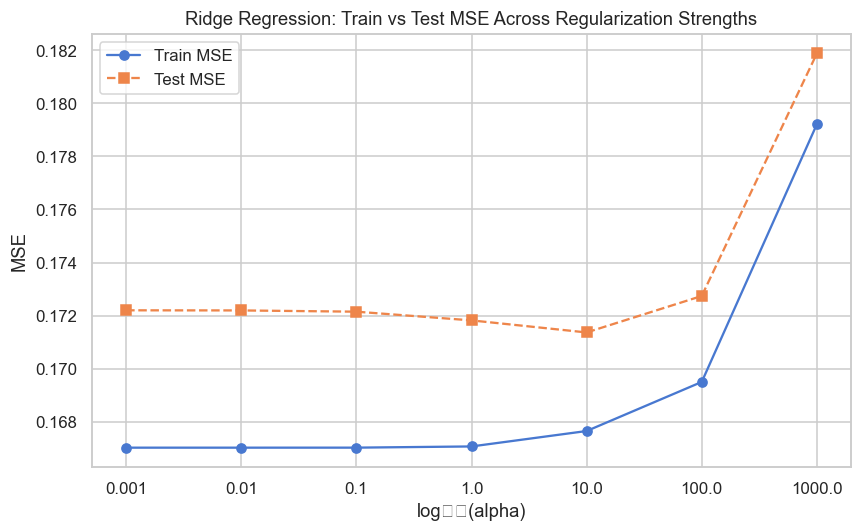

alpha         Train MSE     Test MSE    Test R²
----------------------------------------------
0.001            0.1670       0.1722     0.3024
0.01             0.1670       0.1722     0.3025
0.1              0.1670       0.1721     0.3027
1.0              0.1671       0.1718     0.3040
10.0             0.1676       0.1714     0.3058
100.0            0.1695       0.1727     0.3003
1000.0           0.1792       0.1819     0.2632

Best alpha (lowest test MSE): 10.0


In [4]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
train_mses, test_mses, test_r2s = [], [], []

for alpha in alphas:
    ridge = RidgeRegression(alpha=alpha)
    ridge.fit(X_train_s, y_train)
    train_mses.append(mse(y_train, ridge.predict(X_train_s)))
    y_pred_r = ridge.predict(X_test_s)
    test_mses.append(mse(y_test, y_pred_r))
    test_r2s.append(r2_score(y_test, y_pred_r))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
log_alphas = np.log10(alphas)
ax.plot(log_alphas, train_mses, 'o-',  label='Train MSE')
ax.plot(log_alphas, test_mses,  's--', label='Test MSE')
ax.set_xlabel('log₁₀(alpha)')
ax.set_ylabel('MSE')
ax.set_title('Ridge Regression: Train vs Test MSE Across Regularization Strengths')
ax.set_xticks(log_alphas)
ax.set_xticklabels([str(a) for a in alphas])
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ridge_alpha_sweep.png'), bbox_inches='tight')
plt.show()

# ── Numeric table ────────────────────────────────────────────────────────────
print(f"{'alpha':<10} {'Train MSE':>12} {'Test MSE':>12} {'Test R²':>10}")
print('-' * 46)
for alpha, tr, te, r2 in zip(alphas, train_mses, test_mses, test_r2s):
    print(f'{alpha:<10} {tr:>12.4f} {te:>12.4f} {r2:>10.4f}')

best_alpha = alphas[int(np.argmin(test_mses))]
print(f'\nBest alpha (lowest test MSE): {best_alpha}')

## 4. Residual Analysis

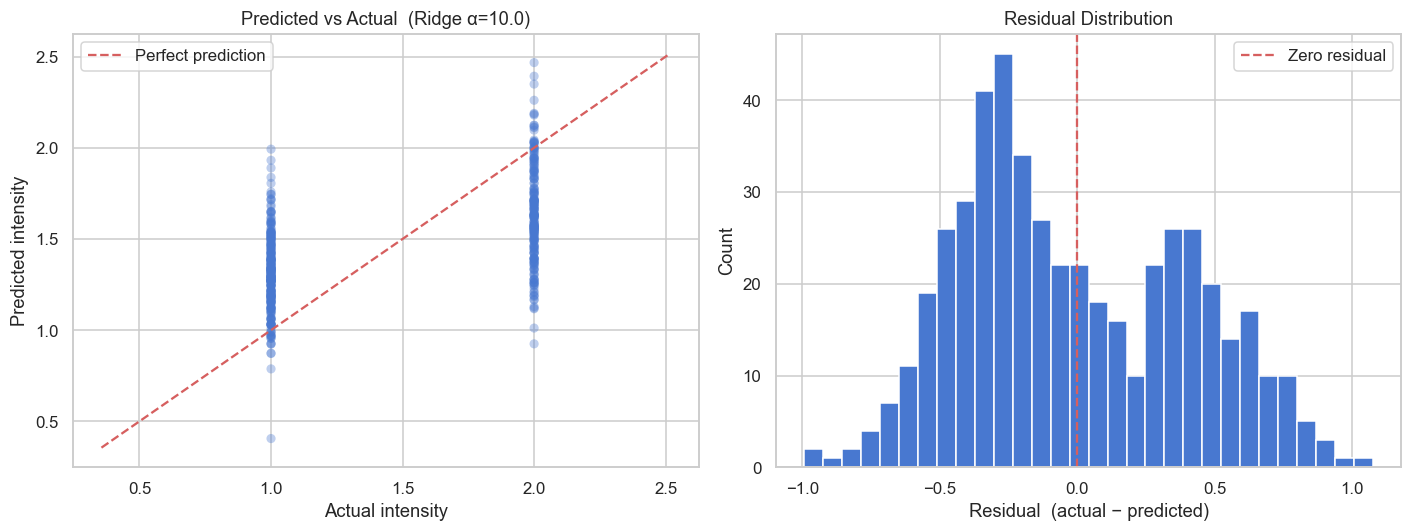

R²   : 0.3058
RMSE : 0.4140
Residual mean : -0.0124
Residual std  : 0.4138


In [5]:
# Refit best Ridge on full train set
ridge_best = RidgeRegression(alpha=best_alpha)
ridge_best.fit(X_train_s, y_train)
y_pred_best = ridge_best.predict(X_test_s)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Predicted vs Actual ───────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_best, alpha=0.35, edgecolors='none')
lo = min(y_test.min(), y_pred_best.min()) - 0.05
hi = max(y_test.max(), y_pred_best.max()) + 0.05
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual intensity')
axes[0].set_ylabel('Predicted intensity')
axes[0].set_title(f'Predicted vs Actual  (Ridge α={best_alpha})')
axes[0].legend()

# ── Residual histogram ────────────────────────────────────────────────────
axes[1].hist(residuals, bins=30, edgecolor='white')
axes[1].axvline(0, color='r', linestyle='--', lw=1.5, label='Zero residual')
axes[1].set_xlabel('Residual  (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residuals.png'), bbox_inches='tight')
plt.show()

print(f'R²   : {r2_score(y_test, y_pred_best):.4f}')
print(f'RMSE : {rmse(y_test, y_pred_best):.4f}')
print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')

## 5. Discussion

*Address:*
- *Does linear regression predict intensity well from audio features?  Why or why not?*
- *How does Ridge regularization affect the bias-variance trade-off on this data?*
- *Do MiniLearn and sklearn produce the same coefficients?*